# Multi-Depot Vehicle Routing Problem (with clustering)
---
Description:

The Multi-Depot Vehicle Routing Problem (MDVRP) is an extension of the Vehicle Routing Problem where a fleet of vehicles is based at 
multiple depots and must serve a set of customers with known demands. The objective is to assign customers to depots and design routes
for vehicles (respecting capacity, time-window, and route-length constraints) that minimize total cost (e.g., distance or time), while 
ensuring all customer demands are satisfied and each route starts and ends at the same depot.

- Optimization (combinatorial)
- Single-objective
- Constraints (yes)
---

### Import python libraries and set up the project directory

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.abspath('../../')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# Multi Depot Vehicles Routing Problem.
from utils import (load_data, euclidean_dist, Cluster, Depot, Customer,
                   initialize_population, cluster_customers_to_depots,
                   evaluate_solution)

### Import the custom GA code

In [2]:
# Import main classes.
from pygenalgo.genome.gene import Gene
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import cost_function
from pygenalgo.engines.standard_ga import StandardGA

# Import Selection Operator(s).
from pygenalgo.operators.selection.tournament_selector import TournamentSelector

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.order_crossover import OrderCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.swap_mutator import SwapMutator

### Read the data and cluster the customers to the depots

In [3]:
# Select a datafile.
# p01_c50_d4_v4
# p02_c50_d4_v2
# p03_c31_d1_v5
filepath = "data/p01_c50_d4_v4.json"

# Load the data from the filepath.
CUSTOMERS, DEPOTS = load_data(filepath)

# Create and store the clusters.
depot_clusters = cluster_customers_to_depots(DEPOTS,
                                             CUSTOMERS,
                                             verbose=True)

Depot-ID: 51 has  13 customers
Depot-ID: 52 has  17 customers
Depot-ID: 53 has  11 customers
Depot-ID: 54 has   9 customers


### Setup the fitness function

In [4]:
# Define the fitness function.
@cost_function(minimize=True)
def func_MDVRP(individual: Chromosome, cluster: Cluster,
               pop_size: int) -> tuple[float, bool]:
    """
    This function computes the total distance
    travelled from all the cars of each depot.
    """
    # Validate the solution.
    total_distance, total_penalty = evaluate_solution(individual, cluster)
    
    # Penalty coefficient.
    p_coeff = 5.0
    
    # Estimate the fitness value.
    f_value = total_distance + (p_coeff * total_penalty)
    
    # Return the total fitness.
    return f_value, False
# _end_def_

In [5]:
# Total distance and penalty values.
total_d, total_p = 0.0, 0

# Store the solutions for plotting.
optimal_solutions = []

# Process all clusters (serially).
for cluster_k in depot_clusters:
    # Extract the depot.
    depot_k = cluster_k.depot
    
    # Extract the customers.
    customers_k = cluster_k.customers
    
    # Create the initial population.
    population_k = initialize_population(customers_k,
                                         depot_k.vehicles,
                                         n_pop=100)
    # Create a StandardGA object.
    test_GA = StandardGA(initial_pop=population_k,
                         fit_func=lambda x: func_MDVRP(x, cluster_k, 100),
                         select_op=TournamentSelector(),
                         crossx_op=OrderCrossover(0.8),
                         mutate_op=SwapMutator(0.2))

    # Optimize the model.
    test_GA(epochs=800, elitism=True, verbose=True)
    
    # Extract the optimal solution from the GA.
    optimal_k = test_GA.best_chromosome()

    # Display an empty line.
    print(" ")
    
    # Extract the validation values.
    dist_k, pnlt_k = evaluate_solution(optimal_k, cluster_k,
                                       verbose=True)
    # Add the output values.
    total_d += dist_k
    total_p += pnlt_k

    # Store the optimal_k solution.
    optimal_solutions.append(optimal_k)

04/26/2026 17:04:40 INFO: Initial Avg. Fitness = -342.5675
04/26/2026 17:04:40 INFO: Epoch:     1 -> Avg. Fitness = -316.1276, Spread = 54.4137
04/26/2026 17:04:43 INFO: Epoch:    81 -> Avg. Fitness = -198.4945, Spread = 33.4750
04/26/2026 17:04:46 INFO: Epoch:   161 -> Avg. Fitness = -188.7237, Spread = 22.5600
04/26/2026 17:04:48 INFO: Epoch:   241 -> Avg. Fitness = -196.4309, Spread = 32.3465
04/26/2026 17:04:50 INFO: Epoch:   321 -> Avg. Fitness = -192.6950, Spread = 30.1008
04/26/2026 17:04:52 INFO: Epoch:   401 -> Avg. Fitness = -187.8683, Spread = 18.1025
04/26/2026 17:04:55 INFO: Epoch:   481 -> Avg. Fitness = -188.4130, Spread = 27.0403
04/26/2026 17:04:58 INFO: Epoch:   561 -> Avg. Fitness = -192.4618, Spread = 29.3399
04/26/2026 17:05:00 INFO: Epoch:   641 -> Avg. Fitness = -199.7806, Spread = 39.9051
04/26/2026 17:05:02 INFO: Epoch:   721 -> Avg. Fitness = -190.4921, Spread = 26.3322
04/26/2026 17:05:04 INFO: Final   Avg. Fitness = -187.4978
04/26/2026 17:05:04 INFO: Initia

Elapsed time: 23.642 seconds.
 
Depot-ID 51: -> Route 0, Distance 51.17, Demand 51
Depot-ID 51: -> Route 1, Distance 51.75, Demand 56
Depot-ID 51: -> Route 2, Distance 26.96, Demand 50
Depot-ID 51: -> Route 3, Distance 48.11, Demand 48


04/26/2026 17:05:07 INFO: Epoch:    81 -> Avg. Fitness = -279.2507, Spread = 61.3778
04/26/2026 17:05:09 INFO: Epoch:   161 -> Avg. Fitness = -273.7206, Spread = 66.1834
04/26/2026 17:05:12 INFO: Epoch:   241 -> Avg. Fitness = -252.3292, Spread = 45.3117
04/26/2026 17:05:14 INFO: Epoch:   321 -> Avg. Fitness = -259.7251, Spread = 48.5059
04/26/2026 17:05:17 INFO: Epoch:   401 -> Avg. Fitness = -267.4601, Spread = 68.4616
04/26/2026 17:05:21 INFO: Epoch:   481 -> Avg. Fitness = -263.8942, Spread = 54.9183
04/26/2026 17:05:23 INFO: Epoch:   561 -> Avg. Fitness = -266.7964, Spread = 53.4516
04/26/2026 17:05:26 INFO: Epoch:   641 -> Avg. Fitness = -266.8088, Spread = 50.4296
04/26/2026 17:05:29 INFO: Epoch:   721 -> Avg. Fitness = -269.9532, Spread = 68.0804
04/26/2026 17:05:32 INFO: Final   Avg. Fitness = -272.2060
04/26/2026 17:05:32 INFO: Initial Avg. Fitness = -198.6116
04/26/2026 17:05:32 INFO: Epoch:     1 -> Avg. Fitness = -184.5348, Spread = 23.0192


Elapsed time: 27.605 seconds.
 
Depot-ID 52: -> Route 0, Distance 39.81, Demand 36
Depot-ID 52: -> Route 1, Distance 42.08, Demand 78
Depot-ID 52: -> Route 2, Distance 80.58, Demand 73
Depot-ID 52: -> Route 3, Distance 72.38, Demand 75


04/26/2026 17:05:34 INFO: Epoch:    81 -> Avg. Fitness = -129.1311, Spread = 24.2084
04/26/2026 17:05:35 INFO: Epoch:   161 -> Avg. Fitness = -124.6167, Spread = 25.9579
04/26/2026 17:05:37 INFO: Epoch:   241 -> Avg. Fitness = -126.0251, Spread = 25.4252
04/26/2026 17:05:39 INFO: Epoch:   321 -> Avg. Fitness = -122.3439, Spread = 16.0474
04/26/2026 17:05:41 INFO: Epoch:   401 -> Avg. Fitness = -127.1830, Spread = 20.9657
04/26/2026 17:05:43 INFO: Epoch:   481 -> Avg. Fitness = -122.2599, Spread = 14.1274
04/26/2026 17:05:45 INFO: Epoch:   561 -> Avg. Fitness = -122.3375, Spread = 12.1750
04/26/2026 17:05:47 INFO: Epoch:   641 -> Avg. Fitness = -122.1968, Spread = 12.6927
04/26/2026 17:05:48 INFO: Epoch:   721 -> Avg. Fitness = -122.6502, Spread = 14.4668
04/26/2026 17:05:50 INFO: Final   Avg. Fitness = -125.1846
04/26/2026 17:05:50 INFO: Initial Avg. Fitness = -188.5163
04/26/2026 17:05:50 INFO: Epoch:     1 -> Avg. Fitness = -181.6045, Spread = 26.6444


Elapsed time: 18.403 seconds.
 
Depot-ID 53: -> Route 1, Distance 35.07, Demand 62
Depot-ID 53: -> Route 2, Distance 25.22, Demand 54
Depot-ID 53: -> Route 3, Distance 55.65, Demand 61


04/26/2026 17:05:52 INFO: Epoch:    81 -> Avg. Fitness = -128.7669, Spread = 27.6171
04/26/2026 17:05:54 INFO: Epoch:   161 -> Avg. Fitness = -138.3577, Spread = 39.8210
04/26/2026 17:05:55 INFO: Epoch:   241 -> Avg. Fitness = -131.6174, Spread = 40.4995
04/26/2026 17:05:57 INFO: Epoch:   321 -> Avg. Fitness = -133.7644, Spread = 42.0267
04/26/2026 17:05:58 INFO: Epoch:   401 -> Avg. Fitness = -126.6045, Spread = 33.3367
04/26/2026 17:06:00 INFO: Epoch:   481 -> Avg. Fitness = -127.3209, Spread = 35.9908
04/26/2026 17:06:02 INFO: Epoch:   561 -> Avg. Fitness = -132.8553, Spread = 35.9581
04/26/2026 17:06:03 INFO: Epoch:   641 -> Avg. Fitness = -128.2910, Spread = 32.5909
04/26/2026 17:06:05 INFO: Epoch:   721 -> Avg. Fitness = -123.5778, Spread = 18.3531
04/26/2026 17:06:07 INFO: Final   Avg. Fitness = -131.2400


Elapsed time: 16.740 seconds.
 
Depot-ID 54: -> Route 1, Distance 44.64, Demand 57
Depot-ID 54: -> Route 2, Distance 69.30, Demand 76


### Display the final solution along with the plot of the vehicles routes

Depot[51] -> [13] -> [25] -> [51] 
Depot[51] -> [41] -> [40] -> [19] -> [42] -> [51] 
Depot[51] -> [18] -> [4] -> [51] 
Depot[51] -> [44] -> [45] -> [15] -> [37] -> [17] -> [51] 
Depot[52] -> [6] -> [14] -> [52] 
Depot[52] -> [46] -> [11] -> [12] -> [47] -> [52] 
Depot[52] -> [48] -> [23] -> [7] -> [43] -> [24] -> [52] 
Depot[52] -> [32] -> [1] -> [31] -> [26] -> [8] -> [27] -> [52] 
Depot[53] -> [9] -> [16] -> [50] -> [34] -> [53] 
Depot[53] -> [38] -> [5] -> [49] -> [53] 
Depot[53] -> [30] -> [39] -> [33] -> [10] -> [53] 
Depot[54] -> [35] -> [36] -> [20] -> [29] -> [54] 
Depot[54] -> [3] -> [28] -> [22] -> [2] -> [21] -> [54] 


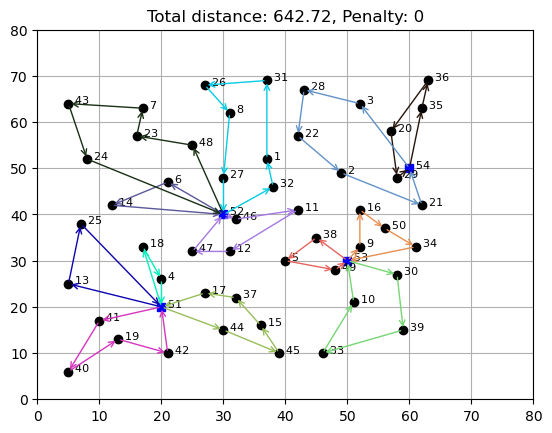

In [7]:
# Fix the rng for the colours.
fixed_rng = np.random.default_rng(756983756837456289375)

# Create a new figure.
fig = plt.figure()
ax = fig.add_subplot(111)

for optimal_k, cluster_k in zip(optimal_solutions,
                                depot_clusters):
    depot_k = cluster_k.depot

    n_vehicles = depot_k.vehicles
    
    customers_k = cluster_k.customers

    n_customers = len(customers_k)

    # Add the customers.
    for c in customers_k:
        ax.plot(c.x, c.y, 'ko')
        ax.annotate(f'  {c.ID}', xy=(c.x, c.y), fontsize=8)
    # _end_for_

    # Add the depot.
    ax.plot(depot_k.x, depot_k.y, 'bs')
    ax.annotate(f'  {depot_k.ID}',
                xy=(depot_k.x, depot_k.y), fontsize=8)

    # Reshape the solution array.
    final_k = np.reshape(optimal_k.values(),
                         (n_customers, n_vehicles))

    # Start computing the total cost.
    for i in range(n_vehicles):
        # Exclude the negative entries.
        customer_ids = final_k[final_k[:, i] >= 0, i]

        # If the array is emtpy
        # continue to the next.
        if customer_ids.size == 0:
            continue

        # Initialize the route using
        # the depot as starting point.
        route = [depot_k]

        # Start printing the route info.
        print(f"Depot[{depot_k.ID}]", end="")

        # Generate the route for this vehicle.
        for c_id in customer_ids.tolist():
            for customer_i in customers_k:
                if customer_i.ID == c_id:
                    route.append(customer_i)
        # _end_for_

        # Get the length of the route.
        n_stops = len(route)

        # Generate a random colour for the route.
        color_i = fixed_rng.random(3)
        
        # Iterate through the route.
        for j, start_point in enumerate(route):
            # Get the coordinates of the first point.
            xj, yj = start_point.x, start_point.y
    
            # The next index ('k') should point
            # at the beginning of the list once
            # we reach at the end.
            k = j + 1 if j < n_stops - 1 else 0
    
            # Get the coordinates of the both points.
            xk, yk = route[k].x, route[k].y
    
            # Put an arrow to show direction.
            ax.annotate("", xy=(xj, yj), xytext=(xk, yk),
                        arrowprops=dict(arrowstyle="<-",
                                        color=color_i))
            # Print the next stop.
            print(f" -> [{route[k].ID}]", end="")
        # _end_for_

        # Print a new line to declater the screen.
        print(" ")
# _end_for_

ax.grid()
ax.set_xlim([0, 80])
ax.set_ylim([0, 80])

plt.title(f"Total distance: {total_d:.2f}, Penalty: {total_p}")

# Save the figure.
plt.savefig("MDVRP_cluster.pdf", format="pdf", dpi=300)

### End-Of-File